In [1]:
import pandas as pd
import seaborn as sns
import openpyxl

In [8]:

df = pd.read_excel("data/Student_performance_data.xlsx")
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   int64  
dtypes: float64(2), int64(13)
memory usage: 280.4 KB


In [12]:
df.isna().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [13]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [14]:
df['Result'] = df['GPA'].apply(lambda x: 1 if x >= 1.6 else 0)
df['Result'].value_counts()

Result
1    1441
0     951
Name: count, dtype: int64

In [15]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,Result
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2,1
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4,0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3,1
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4,0


In [40]:
## Separating target variable(dependent) and independent vaariable for our study
x = df.drop(['Result', 'StudentID', 'GPA', 'GradeClass'], axis=1) # result is classified from GPA , Result is itself a dependent variable and student
#ID doesnot play role in result so we are dropping it.


# Target
y = df['Result']

In [17]:
x

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,1
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,4
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,3
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,1,0,3,10.680555,2,0,4,1,0,0,0,0
2388,17,0,0,1,7.583217,4,1,4,0,1,0,0,4
2389,16,1,0,2,6.805500,20,0,2,0,0,0,1,2
2390,16,1,1,0,12.416653,17,0,2,0,1,1,0,1


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [42]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.linear_model import LogisticRegression

# Initialize model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)


Logistic Regression Accuracy: 0.9248434237995825
Random Forest Accuracy: 0.918580375782881


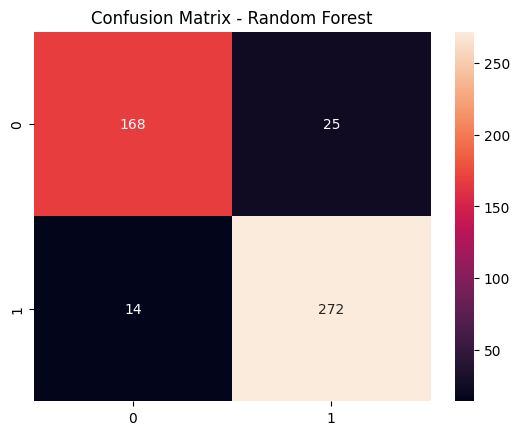

              precision    recall  f1-score   support

           0       0.92      0.87      0.90       193
           1       0.92      0.95      0.93       286

    accuracy                           0.92       479
   macro avg       0.92      0.91      0.91       479
weighted avg       0.92      0.92      0.92       479



In [45]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix for Random Forest
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Classification Report for Random Forest
print(classification_report(y_test, y_pred_rf))

              Feature  Importance
5            Absences    0.720769
4     StudyTimeWeekly    0.090567
7     ParentalSupport    0.037775
3   ParentalEducation    0.028122
0                 Age    0.026268
2           Ethnicity    0.021741
6            Tutoring    0.017976
9              Sports    0.013147
10              Music    0.012814
1              Gender    0.011631
8     Extracurricular    0.010463
11       Volunteering    0.008728


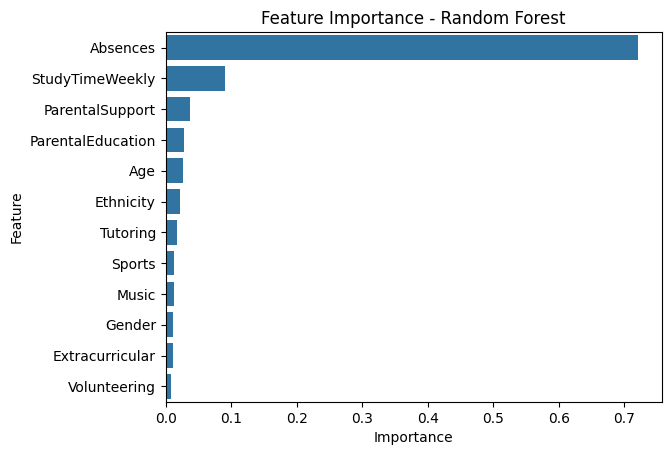

In [46]:
import pandas as pd

feat_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display & plot
print(feat_importance)

sns.barplot(x="Importance", y="Feature", data=feat_importance)
plt.title("Feature Importance - Random Forest")
plt.show()

In [65]:
x1 = df.drop(['Result', 'StudentID', 'GPA', 'GradeClass', 'Sports', 'Music', 'Gender','Extracurricular','Volunteering'], axis = 1)
y1 = df['Result']

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X1_scaled = scaler.fit_transform(x1)

In [67]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1_scaled, y1, test_size=0.2, random_state=42
)

In [68]:
from sklearn.linear_model import LogisticRegression

# Initialize model
lr_model1 = LogisticRegression()

# Train model
lr_model1.fit(X1_train, y1_train)

# Predict on test set
y_pred_lr1 = lr_model1.predict(X1_test)

In [69]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model1 = RandomForestClassifier(n_estimators=100, random_state=42)

# Train model
rf_model1.fit(X1_train, y1_train)

# Predict on test set
y_pred_rf1 = rf_model1.predict(X1_test)


Logistic Regression Accuracy: 0.918580375782881
Random Forest Accuracy: 0.9081419624217119


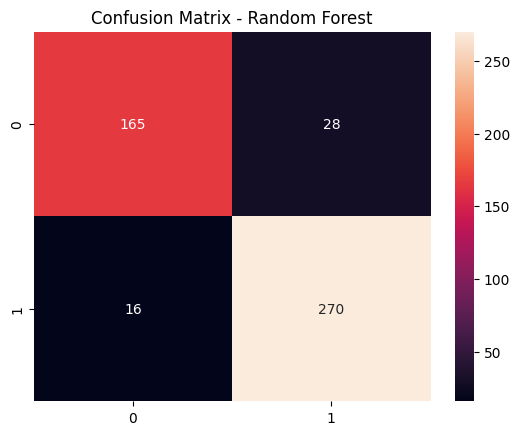

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       193
           1       0.91      0.94      0.92       286

    accuracy                           0.91       479
   macro avg       0.91      0.90      0.90       479
weighted avg       0.91      0.91      0.91       479



In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y1_test, y_pred_lr1))
print("Random Forest Accuracy:", accuracy_score(y1_test, y_pred_rf1))

# Confusion Matrix for Random Forest
sns.heatmap(confusion_matrix(y1_test, y_pred_rf1), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Classification Report for Random Forest
print(classification_report(y1_test, y_pred_rf1))

             Feature  Importance
4           Absences    0.736702
3    StudyTimeWeekly    0.115855
6    ParentalSupport    0.040103
2  ParentalEducation    0.032493
0                Age    0.030254
1          Ethnicity    0.026395
5           Tutoring    0.018199


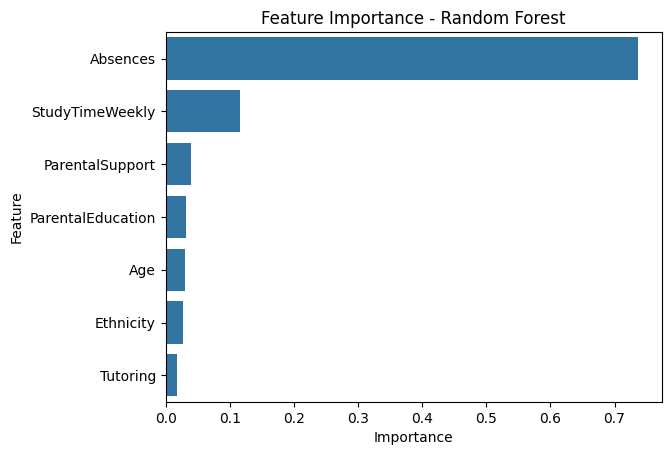

In [71]:
import pandas as pd

feat_importance = pd.DataFrame({
    "Feature": x1.columns,
    "Importance": rf_model1.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Display & plot
print(feat_importance)

sns.barplot(x="Importance", y="Feature", data=feat_importance)
plt.title("Feature Importance - Random Forest")
plt.show()